In [23]:
pip install pandas numpy matplotlib scikit-learn yfinance seaborn

Note: you may need to restart the kernel to use updated packages.


In [25]:
!pip install yfinance scikit-learn matplotlib pandas

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

In [26]:
import sys
!{sys.executable} -m pip install yfinance

'c:\Users\My' is not recognized as an internal or external command,
operable program or batch file.


In [27]:
import sys
print(sys.executable)

c:\Users\My Pc\AppData\Local\Programs\Python\Python312\python.exe


In [28]:
pip install yfinance

Note: you may need to restart the kernel to use updated packages.


In [29]:
import yfinance as yf

data = yf.download("AAPL", period="5d")
print(data.head())

[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open    Volume
Ticker            AAPL        AAPL        AAPL        AAPL      AAPL
Date                                                                
2026-03-17  254.229996  255.130005  252.179993  252.960007  32361600
2026-03-18  249.940002  254.940002  249.000000  252.630005  35757900
2026-03-19  248.960007  251.830002  247.300003  249.399994  34864100
2026-03-20  247.990005  249.199997  246.000000  247.979996  88268000
2026-03-23  251.419998  254.559998  250.279999  253.990005  21572583


In [30]:
stock = "AAPL"  # You can change to TSLA, MSFT, etc.
data = yf.download(stock, start="2020-01-01", end="2024-01-01")

data.head()

[*********************100%***********************]  1 of 1 completed

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.400505,72.460769,71.156667,71.409770,135480400
2020-01-03,71.696625,72.455943,71.472447,71.629130,146322800
2020-01-06,72.267921,72.306491,70.568495,70.819193,118387200
2020-01-07,71.928055,72.533095,71.708695,72.277578,108872000
2020-01-08,73.085106,73.386423,71.631552,71.631552,132079200


In [31]:
data['Next_Close'] = data['Close'].shift(-1)
data = data.dropna()

features = ['Open', 'High', 'Low', 'Volume']
X = data[features]
y = data['Next_Close']

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

In [33]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_preds = lr_model.predict(X_test)

In [34]:
rf_model = RandomForestRegressor(n_estimators=100)
rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

In [35]:
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))

print("Linear Regression RMSE:", lr_rmse)
print("Random Forest RMSE:", rf_rmse)

Linear Regression RMSE: 2.2239509680778835
Random Forest RMSE: 10.197249647570047


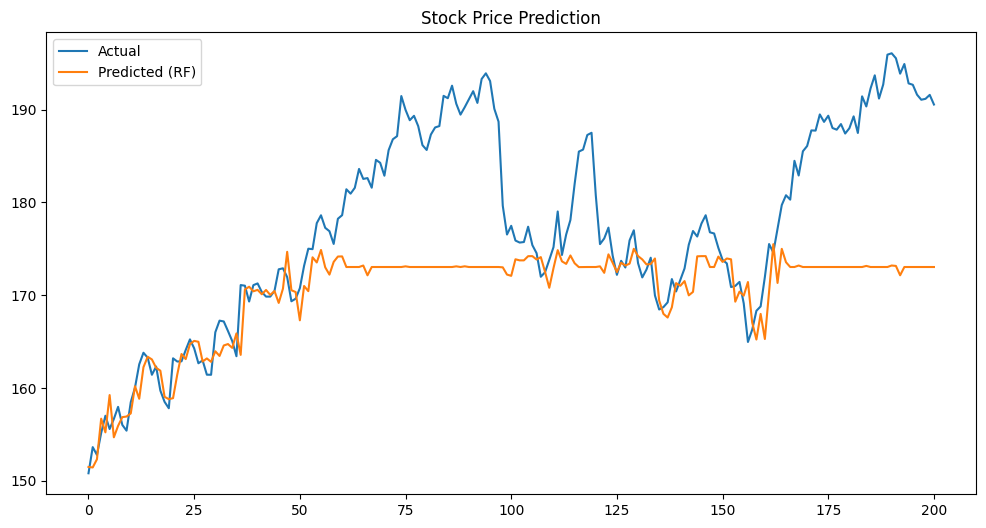

In [36]:
plt.figure(figsize=(12,6))
plt.plot(y_test.values, label="Actual")
plt.plot(rf_preds, label="Predicted (RF)")
plt.legend()
plt.title("Stock Price Prediction")
plt.show()

In [37]:
latest = data[features].iloc[-1].values.reshape(1, -1)
next_day_price = rf_model.predict(latest)

print("Predicted Next Day Closing Price:", next_day_price[0])

Predicted Next Day Closing Price: 173.03681915283204
